In [3]:
!pip install mysql-connector-python


In [1]:
import pandas as pd
import mysql.connector

conn = mysql.connector.connect(
    host="localhost",
    user="root",
    password="Myazeem@123",
    database="securitization_project"
)

query = "SELECT * FROM loans"

df = pd.read_sql(query, conn)

df.head()

C:\Users\sazee\AppData\Local\Temp\ipykernel_19408\1274105297.py:13: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


,ï»¿Loan_ID,Borrower_ID,Pool_ID,Deal_ID,Asset_Class,Origination_Date,Original_Balance,Current_Balance,Interest_Rate,Loan_Term_Months,...,Employment_Type,State,Debt_to_Income_Proxy,Delinquency_Bucket,Risk_Category,FALSE,negative balance check,STATUS DPD CHECK,Original_Balance_Num,Current_Balance_Num
0,LN000001,BR00001,POOL001,DEAL001,Residential Mortgage,29-01-2024,"â‚¹ 26,08,945.00","â‚¹ 20,10,252.00",11.07,120,...,Business Owner,Rajasthan,0.780,Current,Medium,FALSE,FALSE,FALSE,2608945.0,2010252.0
1,LN000002,BR00002,POOL001,DEAL001,Residential Mortgage,03-10-2024,"â‚¹ 57,76,447.00","â‚¹ 53,16,374.00",8.77,180,...,Salaried,Delhi,0.447,Current,Medium,FALSE,FALSE,FALSE,5776447.0,5316374.0
2,LN000003,BR00003,POOL001,DEAL001,Residential Mortgage,03-05-2023,"â‚¹ 38,22,229.00","â‚¹ 32,96,822.00",11.00,240,...,Salaried,Delhi,0.694,61-90 DPD,High,FALSE,FALSE,FALSE,3822229.0,3296822.0
3,LN000004,BR00004,POOL001,DEAL001,Residential Mortgage,24-03-2023,"â‚¹ 50,03,406.00","â‚¹ 44,08,802.00",8.47,300,...,Business Owner,Delhi,1.007,Current,Medium,FALSE,FALSE,FALSE,5003406.0,4408802.0
4,LN000005,BR00005,POOL001,DEAL001,Residential Mortgage,02-04-2023,"â‚¹ 13,40,183.00","â‚¹ 11,81,549.00",11.18,240,...,Business Owner,Maharashtra,0.250,Current,Medium,FALSE,FALSE,FALSE,1340183.0,1181549.0


In [2]:
df.shape

(5000, 29)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 29 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   ï»¿Loan_ID              5000 non-null   object 
 1   Borrower_ID             5000 non-null   object 
 2   Pool_ID                 5000 non-null   object 
 3   Deal_ID                 5000 non-null   object 
 4   Asset_Class             5000 non-null   object 
 5   Origination_Date        5000 non-null   object 
 6   Original_Balance        5000 non-null   object 
 7   Current_Balance         5000 non-null   object 
 8   Interest_Rate           5000 non-null   float64
 9   Loan_Term_Months        5000 non-null   int64  
 10  Remaining_Term_Months   5000 non-null   int64  
 11  Monthly_Payment         5000 non-null   object 
 12  Payment_Status          5000 non-null   object 
 13  Days_Past_Due           5000 non-null   int64  
 14  Prepayment_Amount       5000 non-null   

In [8]:
df.isnull().sum()

ï»¿Loan_ID                0
Borrower_ID               0
Pool_ID                   0
Deal_ID                   0
Asset_Class               0
Origination_Date          0
Original_Balance          0
Current_Balance           0
Interest_Rate             0
Loan_Term_Months          0
Remaining_Term_Months     0
Monthly_Payment           0
Payment_Status            0
Days_Past_Due             0
Prepayment_Amount         0
Default_Flag              0
Recovery_Amount           0
Credit_Score              0
Annual_Income             0
Employment_Type           0
State                     0
Debt_to_Income_Proxy      0
Delinquency_Bucket        0
Risk_Category             0
FALSE                     0
negative balance check    0
STATUS DPD  CHECK         0
Original_Balance_Num      0
Current_Balance_Num       0
dtype: int64

In [9]:
df['Credit_Score_Num'] = pd.to_numeric(
    df['Credit_Score'].astype(str).str.replace(',', '').str.strip(),
    errors='coerce'
)

df['Annual_Income_Num'] = pd.to_numeric(
    df['Annual_Income'].astype(str).str.replace(r'[^\d.]', '', regex=True),
    errors='coerce'
)

df['Monthly_Payment_Num'] = pd.to_numeric(
    df['Monthly_Payment'].astype(str).str.replace(r'[^\d.]', '', regex=True),
    errors='coerce'
)

df['Prepayment_Amount_Num'] = pd.to_numeric(
    df['Prepayment_Amount'].astype(str).str.replace(r'[^\d.]', '', regex=True),
    errors='coerce'
)

In [10]:
df[['Credit_Score_Num',
    'Annual_Income_Num',
    'Monthly_Payment_Num',
    'Prepayment_Amount_Num']].head()

,Credit_Score_Num,Annual_Income_Num,Monthly_Payment_Num,Prepayment_Amount_Num
0,698,554476.0,36046.0,0.0
1,666,1551039.0,57805.0,3317823.0
2,789,681905.0,39453.0,0.0
3,700,478853.0,40199.0,0.0
4,682,672344.0,14001.0,0.0


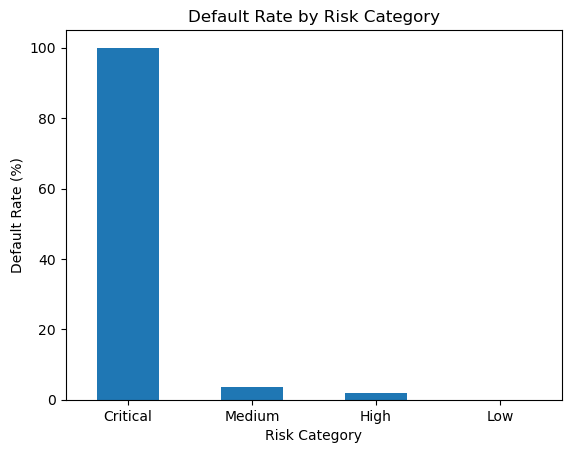

In [11]:
import matplotlib.pyplot as plt

risk_default = (
    df.groupby('Risk_Category')['Default_Flag']
      .mean()
      .mul(100)
      .sort_values(ascending=False)
)

risk_default.plot(kind='bar')

plt.title('Default Rate by Risk Category')
plt.xlabel('Risk Category')
plt.ylabel('Default Rate (%)')
plt.xticks(rotation=0)
plt.show()

In [13]:
df.dtypes

ï»¿Loan_ID                 object
Borrower_ID                object
Pool_ID                    object
Deal_ID                    object
Asset_Class                object
Origination_Date           object
Original_Balance           object
Current_Balance            object
Interest_Rate             float64
Loan_Term_Months            int64
Remaining_Term_Months       int64
Monthly_Payment            object
Payment_Status             object
Days_Past_Due               int64
Prepayment_Amount          object
Default_Flag                int64
Recovery_Amount             int64
Credit_Score                int64
Annual_Income              object
Employment_Type            object
State                      object
Debt_to_Income_Proxy      float64
Delinquency_Bucket         object
Risk_Category              object
FALSE                      object
negative balance check     object
STATUS DPD  CHECK          object
Original_Balance_Num      float64
Current_Balance_Num       float64
Credit_Score_N

In [14]:
X = df.drop(columns=['Default_Flag'])
y = df['Default_Flag']

print(X.shape)
print(y.value_counts())

(5000, 32)
Default_Flag
0    4834
1     166
Name: count, dtype: int64


In [17]:
features = [
    'Original_Balance_Num',
    'Current_Balance_Num',
    'Interest_Rate',
    'Loan_Term_Months',
    'Remaining_Term_Months',
    'Monthly_Payment_Num',
    'Days_Past_Due',
    'Prepayment_Amount_Num',
    'Credit_Score_Num',
    'Annual_Income_Num',
    'Debt_to_Income_Proxy',
    'Employment_Type',
    'Asset_Class',
    'State'
]

X = df[features]
y = df['Default_Flag']

print(X.shape)
print(X.head())

(5000, 14)
   Original_Balance_Num  Current_Balance_Num  Interest_Rate  Loan_Term_Months  \
0             2608945.0            2010252.0          11.07               120   
1             5776447.0            5316374.0           8.77               180   
2             3822229.0            3296822.0          11.00               240   
3             5003406.0            4408802.0           8.47               300   
4             1340183.0            1181549.0          11.18               240   

   Remaining_Term_Months  Monthly_Payment_Num  Days_Past_Due  \
0                     90              36046.0              0   
1                    159              57805.0              0   
2                    202              39453.0             75   
3                    260              40199.0              0   
4                    201              14001.0              0   

   Prepayment_Amount_Num  Credit_Score_Num  Annual_Income_Num  \
0                    0.0               698          

In [18]:
X = pd.get_dummies(
    X,
    columns=['Employment_Type', 'Asset_Class', 'State'],
    drop_first=True
)

print(X.shape)
print(X.dtypes)

(5000, 25)
Original_Balance_Num                float64
Current_Balance_Num                 float64
Interest_Rate                       float64
Loan_Term_Months                      int64
Remaining_Term_Months                 int64
Monthly_Payment_Num                 float64
Days_Past_Due                         int64
Prepayment_Amount_Num               float64
Credit_Score_Num                      int64
Annual_Income_Num                   float64
Debt_to_Income_Proxy                float64
Employment_Type_Contract               bool
Employment_Type_Salaried               bool
Employment_Type_Self-Employed          bool
Asset_Class_Consumer Loan              bool
Asset_Class_Residential Mortgage       bool
State_Gujarat                          bool
State_Haryana                          bool
State_Karnataka                        bool
State_Maharashtra                      bool
State_Rajasthan                        bool
State_Tamil Nadu                       bool
State_Telangana      

In [19]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

(4000, 25)
(1000, 25)


In [20]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

model = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    random_state=42
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.977

Confusion Matrix:
[[944  23]
 [  0  33]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.98      0.99       967
           1       0.59      1.00      0.74        33

    accuracy                           0.98      1000
   macro avg       0.79      0.99      0.86      1000
weighted avg       0.99      0.98      0.98      1000



C:\Users\sazee\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [22]:
model = LogisticRegression(
    class_weight='balanced',
    max_iter=5000,
    random_state=42
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.977

Confusion Matrix:
[[944  23]
 [  0  33]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.98      0.99       967
           1       0.59      1.00      0.74        33

    accuracy                           0.98      1000
   macro avg       0.79      0.99      0.86      1000
weighted avg       0.99      0.98      0.98      1000



C:\Users\sazee\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 5000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=5000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [23]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

model = Pipeline([
    ("scaler", StandardScaler()),
    ("logistic", LogisticRegression(
        class_weight="balanced",
        max_iter=2000,
        random_state=42
    ))
])

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.979

Confusion Matrix:
[[946  21]
 [  0  33]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.98      0.99       967
           1       0.61      1.00      0.76        33

    accuracy                           0.98      1000
   macro avg       0.81      0.99      0.87      1000
weighted avg       0.99      0.98      0.98      1000



In [24]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    class_weight="balanced",
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, rf_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, rf_pred))

print("\nClassification Report:")
print(classification_report(y_test, rf_pred))

Random Forest Accuracy: 1.0

Confusion Matrix:
[[967   0]
 [  0  33]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       967
           1       1.00      1.00      1.00        33

    accuracy                           1.00      1000
   macro avg       1.00      1.00      1.00      1000
weighted avg       1.00      1.00      1.00      1000



In [25]:
import pandas as pd
import matplotlib.pyplot as plt

importance = pd.Series(
    rf_model.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

print(importance)

Days_Past_Due                       0.786022
Credit_Score_Num                    0.029409
Original_Balance_Num                0.022748
Remaining_Term_Months               0.021406
Current_Balance_Num                 0.020353
Interest_Rate                       0.019910
Debt_to_Income_Proxy                0.019443
Annual_Income_Num                   0.019293
Monthly_Payment_Num                 0.017545
Prepayment_Amount_Num               0.008891
Loan_Term_Months                    0.008059
State_Uttar Pradesh                 0.006893
State_Maharashtra                   0.002686
Asset_Class_Consumer Loan           0.002384
State_Karnataka                     0.002301
Employment_Type_Salaried            0.002058
State_Tamil Nadu                    0.001896
State_Telangana                     0.001570
Employment_Type_Self-Employed       0.001547
State_Rajasthan                     0.001474
State_Gujarat                       0.001041
Employment_Type_Contract            0.001017
State_West

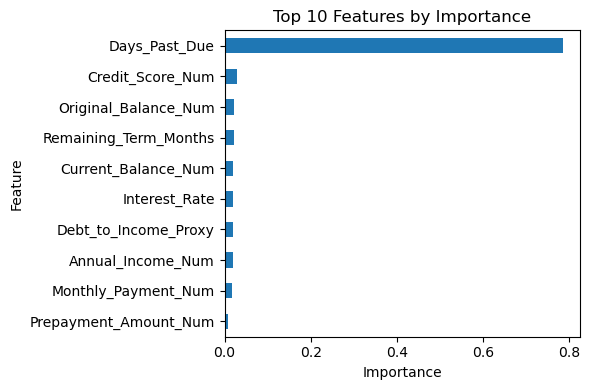

In [27]:
import matplotlib.pyplot as plt

importance.head(10).sort_values().plot(
    kind='barh',
    figsize=(6, 4)
)

plt.title("Top 10 Features by Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

In [28]:
pd.crosstab(df['Days_Past_Due'], df['Default_Flag'])

Default_Flag,0,1
Days_Past_Due,,
0,4342,0
1,70,0
15,69,0
30,75,0
45,67,0
60,58,0
75,75,0
90,78,0
91,0,37


In [29]:
df.groupby('Default_Flag')['Days_Past_Due'].describe()


,count,mean,std,min,25%,50%,75%,max
Default_Flag,,,,,,,,
0,4834.0,4.653496,16.876792,0.0,0.0,0.0,0.0,90.0
1,166.0,133.054217,31.259279,91.0,120.0,120.0,150.0,180.0


In [30]:
# Remove Days_Past_Due to avoid target leakage

X = df.drop(columns=['Default_Flag', 'Days_Past_Due'])
y = df['Default_Flag']

# Convert categorical variables into dummy variables
X = pd.get_dummies(X, drop_first=True)

print(X.shape)
print(X.head())

(5000, 32280)
   Interest_Rate  Loan_Term_Months  Remaining_Term_Months  Recovery_Amount  \
0          11.07               120                     90                0   
1           8.77               180                    159                0   
2          11.00               240                    202                0   
3           8.47               300                    260                0   
4          11.18               240                    201                0   

   Credit_Score  Debt_to_Income_Proxy  Original_Balance_Num  \
0           698                 0.780             2608945.0   
1           666                 0.447             5776447.0   
2           789                 0.694             3822229.0   
3           700                 1.007             5003406.0   
4           682                 0.250             1340183.0   

   Current_Balance_Num  Credit_Score_Num  Annual_Income_Num  ...  \
0            2010252.0               698           554476.0  ...   
1 

In [31]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

(4000, 32280)
(1000, 32280)


In [32]:
# Remove ID columns and fields that should not be used for prediction

drop_cols = [
    'Default_Flag',
    'Days_Past_Due',
    'Loan_ID',
    'Borrower_ID',
    'Pool_ID',
    'Deal_ID',
    'Risk_Category',
    'Delinquency_Bucket',
    'FALSE',
    'negative_balance_check',
    'STATUS DPD CHECK'
]

X = df.drop(columns=drop_cols, errors='ignore')
y = df['Default_Flag']

# Convert categorical variables into dummy variables
X = pd.get_dummies(X, drop_first=True)

print("Features:", X.shape)
print(X.head())

Features: (5000, 27251)
   Interest_Rate  Loan_Term_Months  Remaining_Term_Months  Recovery_Amount  \
0          11.07               120                     90                0   
1           8.77               180                    159                0   
2          11.00               240                    202                0   
3           8.47               300                    260                0   
4          11.18               240                    201                0   

   Credit_Score  Debt_to_Income_Proxy  Original_Balance_Num  \
0           698                 0.780             2608945.0   
1           666                 0.447             5776447.0   
2           789                 0.694             3822229.0   
3           700                 1.007             5003406.0   
4           682                 0.250             1340183.0   

   Current_Balance_Num  Credit_Score_Num  Annual_Income_Num  ...  \
0            2010252.0               698           554476.0 

In [33]:
# Check categorical columns and their number of unique values

cat_cols = df.select_dtypes(include='object').columns

for col in cat_cols:
    print(col, ":", df[col].nunique())

ï»¿Loan_ID : 5000
Borrower_ID : 5000
Pool_ID : 20
Deal_ID : 5
Asset_Class : 3
Origination_Date : 1689
Original_Balance : 4999
Current_Balance : 4994
Monthly_Payment : 4750
Payment_Status : 4
Prepayment_Amount : 802
Annual_Income : 4995
Employment_Type : 4
State : 10
Delinquency_Bucket : 5
Risk_Category : 4
FALSE : 1
negative balance check : 1
STATUS DPD  CHECK : 1


In [3]:
# Drop ID columns if they still exist


# Convert numerical columns to numeric
numeric_cols = [
    'Original_Balance',
    'Current_Balance',
    'Monthly_Payment',
    'Annual_Income',
    'Prepayment_Amount'
]

for col in numeric_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

# Convert Origination_Date to datetime
if 'Origination_Date' in df.columns:
    df['Origination_Date'] = pd.to_datetime(
        df['Origination_Date'],
        errors='coerce',
        dayfirst=True
    )

print(df.dtypes)

ï»¿Loan_ID                        object
Borrower_ID                       object
Pool_ID                           object
Deal_ID                           object
Asset_Class                       object
Origination_Date          datetime64[ns]
Original_Balance                 float64
Current_Balance                  float64
Interest_Rate                    float64
Loan_Term_Months                   int64
Remaining_Term_Months              int64
Monthly_Payment                  float64
Payment_Status                    object
Days_Past_Due                      int64
Prepayment_Amount                float64
Default_Flag                       int64
Recovery_Amount                    int64
Credit_Score                       int64
Annual_Income                    float64
Employment_Type                   object
State                             object
Debt_to_Income_Proxy             float64
Delinquency_Bucket                object
Risk_Category                     object
FALSE           

In [4]:
print(df.shape)

cat_cols = df.select_dtypes(include='object').columns

for col in cat_cols:
    print(col, ":", df[col].nunique())
    

(5000, 29)
ï»¿Loan_ID : 5000
Borrower_ID : 5000
Pool_ID : 20
Deal_ID : 5
Asset_Class : 3
Payment_Status : 4
Employment_Type : 4
State : 10
Delinquency_Bucket : 5
Risk_Category : 4
FALSE : 1
negative balance check : 1
STATUS DPD  CHECK : 1


In [5]:
# Drop ID and constant columns
drop_cols = [
    'Loan_ID',
    'Borrower_ID',
    'FALSE',
    'negative balance check',
    'STATUS DPD CHECK'
]

df = df.drop(columns=drop_cols, errors='ignore')

# Separate target and features
X = df.drop(columns=['Default_Flag'])
y = df['Default_Flag']

# One-hot encode categorical variables
X = pd.get_dummies(X, drop_first=True)

print("X shape:", X.shape)
print("y shape:", y.shape)
print(X.head())

X shape: (5000, 5061)
y shape: (5000,)
  Origination_Date  Original_Balance  Current_Balance  Interest_Rate  \
0       2024-01-29               NaN              NaN          11.07   
1       2024-10-03               NaN              NaN           8.77   
2       2023-05-03               NaN              NaN          11.00   
3       2023-03-24               NaN              NaN           8.47   
4       2023-04-02               NaN              NaN          11.18   

   Loan_Term_Months  Remaining_Term_Months  Monthly_Payment  Days_Past_Due  \
0               120                     90              NaN              0   
1               180                    159              NaN              0   
2               240                    202              NaN             75   
3               300                    260              NaN              0   
4               240                    201              NaN              0   

   Prepayment_Amount  Recovery_Amount  ...  State_Telangana

In [6]:
# Check missing values
missing = X.isnull().sum()

print(missing[missing > 0].sort_values(ascending=False))

Original_Balance     5000
Current_Balance      5000
Monthly_Payment      5000
Prepayment_Amount    5000
Annual_Income        5000
dtype: int64


In [7]:
print("Total missing values:", X.isnull().sum().sum())

Total missing values: 25000


In [8]:
print(X['Origination_Date'].dtype)

datetime64[ns]


In [9]:
for col in [
    'Original_Balance',
    'Current_Balance',
    'Monthly_Payment',
    'Prepayment_Amount',
    'Annual_Income'
]:
    print("\n", col)
    print(df[col].head())
    print("Original dtype:", df[col].dtype)


 Original_Balance
0   NaN
1   NaN
2   NaN
3   NaN
4   NaN
Name: Original_Balance, dtype: float64
Original dtype: float64

 Current_Balance
0   NaN
1   NaN
2   NaN
3   NaN
4   NaN
Name: Current_Balance, dtype: float64
Original dtype: float64

 Monthly_Payment
0   NaN
1   NaN
2   NaN
3   NaN
4   NaN
Name: Monthly_Payment, dtype: float64
Original dtype: float64

 Prepayment_Amount
0   NaN
1   NaN
2   NaN
3   NaN
4   NaN
Name: Prepayment_Amount, dtype: float64
Original dtype: float64

 Annual_Income
0   NaN
1   NaN
2   NaN
3   NaN
4   NaN
Name: Annual_Income, dtype: float64
Original dtype: float64


In [10]:
print(df[['Original_Balance',
          'Current_Balance',
          'Monthly_Payment',
          'Prepayment_Amount',
          'Annual_Income']].head(10))

   Original_Balance  Current_Balance  Monthly_Payment  Prepayment_Amount  \
0               NaN              NaN              NaN                NaN   
1               NaN              NaN              NaN                NaN   
2               NaN              NaN              NaN                NaN   
3               NaN              NaN              NaN                NaN   
4               NaN              NaN              NaN                NaN   
5               NaN              NaN              NaN                NaN   
6               NaN              NaN              NaN                NaN   
7               NaN              NaN              NaN                NaN   
8               NaN              NaN              NaN                NaN   
9               NaN              NaN              NaN                NaN   

   Annual_Income  
0            NaN  
1            NaN  
2            NaN  
3            NaN  
4            NaN  
5            NaN  
6            NaN  
7          

In [14]:
# Convert currency/numerical columns to numeric

numeric_cols = [
    'Original_Balance',
    'Current_Balance',
    'Monthly_Payment',
    'Annual_Income',
    'Prepayment_Amount'
]

for col in numeric_cols:
    if col in df.columns:
        df[col] = (
            df[col]
            .astype(str)
            .str.replace(r'[^0-9.-]', '', regex=True)
        )
        df[col] = pd.to_numeric(df[col], errors='coerce')

print(df[numeric_cols].head())

   Original_Balance  Current_Balance  Monthly_Payment  Annual_Income  \
0         2608945.0        2010252.0          36046.0       554476.0   
1         5776447.0        5316374.0          57805.0      1551039.0   
2         3822229.0        3296822.0          39453.0       681905.0   
3         5003406.0        4408802.0          40199.0       478853.0   
4         1340183.0        1181549.0          14001.0       672344.0   

   Prepayment_Amount  
0                0.0  
1          3317823.0  
2                0.0  
3                0.0  
4                0.0  


In [15]:
print(df[['Original_Balance',
          'Current_Balance',
          'Monthly_Payment',
          'Prepayment_Amount',
          'Annual_Income']].head())

   Original_Balance  Current_Balance  Monthly_Payment  Prepayment_Amount  \
0         2608945.0        2010252.0          36046.0                0.0   
1         5776447.0        5316374.0          57805.0          3317823.0   
2         3822229.0        3296822.0          39453.0                0.0   
3         5003406.0        4408802.0          40199.0                0.0   
4         1340183.0        1181549.0          14001.0                0.0   

   Annual_Income  
0       554476.0  
1      1551039.0  
2       681905.0  
3       478853.0  
4       672344.0  


In [16]:
print(df[numeric_cols].isnull().sum())

Original_Balance     0
Current_Balance      0
Monthly_Payment      0
Annual_Income        0
Prepayment_Amount    0
dtype: int64


In [17]:
print("Duplicate rows:", df.duplicated().sum())





Duplicate rows: 0


In [18]:
print("Dataset shape:", df.shape)

Dataset shape: (5000, 29)


In [20]:
print(df.dtypes)

ï»¿Loan_ID                 object
Borrower_ID                object
Pool_ID                    object
Deal_ID                    object
Asset_Class                object
Origination_Date           object
Original_Balance          float64
Current_Balance           float64
Interest_Rate             float64
Loan_Term_Months            int64
Remaining_Term_Months       int64
Monthly_Payment           float64
Payment_Status             object
Days_Past_Due               int64
Prepayment_Amount         float64
Default_Flag                int64
Recovery_Amount             int64
Credit_Score                int64
Annual_Income             float64
Employment_Type            object
State                      object
Debt_to_Income_Proxy      float64
Delinquency_Bucket         object
Risk_Category              object
FALSE                      object
negative balance check     object
STATUS DPD  CHECK          object
Original_Balance_Num      float64
Current_Balance_Num       float64
dtype: object


In [21]:
print(df.select_dtypes(include='object').columns.tolist())

['ï»¿Loan_ID', 'Borrower_ID', 'Pool_ID', 'Deal_ID', 'Asset_Class', 'Origination_Date', 'Payment_Status', 'Employment_Type', 'State', 'Delinquency_Bucket', 'Risk_Category', 'FALSE', 'negative balance check', 'STATUS DPD  CHECK']


In [2]:
# Convert Origination_Date to datetime
df['Origination_Date'] = pd.to_datetime(
    df['Origination_Date'],
    errors='coerce',
    dayfirst=True
)

# Check the result
print(df['Origination_Date'].dtype)
print(df['Origination_Date'].head())


datetime64[ns]
0   2024-01-29
1   2024-10-03
2   2023-05-03
3   2023-03-24
4   2023-04-02
Name: Origination_Date, dtype: datetime64[ns]


In [4]:
for col in df.columns:
    print(repr(col))

'ï»¿Loan_ID'
'Borrower_ID'
'Pool_ID'
'Deal_ID'
'Asset_Class'
'Origination_Date'
'Original_Balance'
'Current_Balance'
'Interest_Rate'
'Loan_Term_Months'
'Remaining_Term_Months'
'Monthly_Payment'
'Payment_Status'
'Days_Past_Due'
'Prepayment_Amount'
'Default_Flag'
'Recovery_Amount'
'Credit_Score'
'Annual_Income'
'Employment_Type'
'State'
'Debt_to_Income_Proxy'
'Delinquency_Bucket'
'Risk_Category'
'FALSE'
'negative balance check'
'STATUS DPD  CHECK'
'Original_Balance_Num'
'Current_Balance_Num'


In [5]:
[col for col in df.columns if 'STATUS' in col.upper() or 'DPD' in col.upper()]

['Payment_Status', 'STATUS DPD  CHECK']

In [7]:
for col in df.columns:
    print(repr(col))

'ï»¿Loan_ID'
'Borrower_ID'
'Pool_ID'
'Deal_ID'
'Asset_Class'
'Origination_Date'
'Original_Balance'
'Current_Balance'
'Interest_Rate'
'Loan_Term_Months'
'Remaining_Term_Months'
'Monthly_Payment'
'Payment_Status'
'Days_Past_Due'
'Prepayment_Amount'
'Default_Flag'
'Recovery_Amount'
'Credit_Score'
'Annual_Income'
'Employment_Type'
'State'
'Debt_to_Income_Proxy'
'Delinquency_Bucket'
'Risk_Category'
'FALSE'
'negative balance check'
'STATUS DPD  CHECK'
'Original_Balance_Num'
'Current_Balance_Num'


In [15]:
for col in categorical_cols:
    print("\n", col)
    print(df[col].value_counts(dropna=False))


 Asset_Class
Asset_Class
Residential Mortgage    2000
Consumer Loan           2000
Auto Loan               1000
Name: count, dtype: int64

 Payment_Status
Payment_Status
Current       4104
Delinquent     492
Prepaid        238
Defaulted      166
Name: count, dtype: int64

 Employment_Type
Employment_Type
Salaried          2863
Self-Employed      930
Business Owner     825
Contract           382
Name: count, dtype: int64

 State
State
Uttar Pradesh    813
Maharashtra      730
Karnataka        570
Gujarat          525
Telangana        433
Tamil Nadu       424
Rajasthan        405
Delhi            390
Haryana          364
West Bengal      346
Name: count, dtype: int64

 Delinquency_Bucket
Delinquency_Bucket
Current      4342
1-30 DPD      214
90+ DPD       166
61-90 DPD     153
31-60 DPD     125
Name: count, dtype: int64

 Risk_Category
Risk_Category
Low         1995
Medium      1985
High         946
Critical      74
Name: count, dtype: int64

 FALSE
FALSE
FALSE    5000
Name: count, dtyp

In [14]:
print(df['STATUS DPD CHECK'].value_counts(dropna=False))

STATUS DPD CHECK
FALSE    5000
Name: count, dtype: int64


In [10]:
for col in df.columns:
    if 'STATUS' in col.upper() or 'DPD' in col.upper():
        print(repr(col))

'Payment_Status'
'STATUS DPD  CHECK'


In [11]:
df.columns = df.columns.str.strip().str.replace(r'\s+', ' ', regex=True)

In [12]:
print(df.columns.tolist())

['ï»¿Loan_ID', 'Borrower_ID', 'Pool_ID', 'Deal_ID', 'Asset_Class', 'Origination_Date', 'Original_Balance', 'Current_Balance', 'Interest_Rate', 'Loan_Term_Months', 'Remaining_Term_Months', 'Monthly_Payment', 'Payment_Status', 'Days_Past_Due', 'Prepayment_Amount', 'Default_Flag', 'Recovery_Amount', 'Credit_Score', 'Annual_Income', 'Employment_Type', 'State', 'Debt_to_Income_Proxy', 'Delinquency_Bucket', 'Risk_Category', 'FALSE', 'negative balance check', 'STATUS DPD CHECK', 'Original_Balance_Num', 'Current_Balance_Num']


In [16]:
constant_cols = [col for col in df.columns if df[col].nunique() == 1]

print("Constant columns:", constant_cols)


Constant columns: ['FALSE', 'negative balance check', 'STATUS DPD CHECK']


In [17]:
df.drop(columns=constant_cols, inplace=True)

print("New dataset shape:", df.shape)

New dataset shape: (5000, 26)


In [18]:
df.describe()

,Origination_Date,Interest_Rate,Loan_Term_Months,Remaining_Term_Months,Days_Past_Due,Default_Flag,Recovery_Amount,Credit_Score,Debt_to_Income_Proxy,Original_Balance_Num,Current_Balance_Num
count,5000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5.000000e+03,5000.000000,5000.000000,5.000000e+03,5.000000e+03
mean,2023-07-15 12:09:47.520000256,12.213884,119.973600,85.111400,8.916400,0.033200,2.875357e+04,708.401800,0.440392,1.877386e+06,1.413607e+06
min,2021-01-01 00:00:00,7.000000,36.000000,0.000000,0.000000,0.000000,0.000000e+00,550.000000,0.005000,5.066200e+04,5.432000e+03
25%,2022-04-08 18:00:00,9.490000,60.000000,20.000000,0.000000,0.000000,0.000000e+00,665.000000,0.169000,6.867348e+05,3.062715e+05
50%,2023-07-20 12:00:00,11.400000,84.000000,49.000000,0.000000,0.000000,0.000000e+00,710.000000,0.316000,1.162592e+06,7.570865e+05
75%,2024-11-03 00:00:00,14.410000,180.000000,145.000000,0.000000,0.000000,0.000000e+00,751.000000,0.571000,2.706888e+06,2.248280e+06
max,2025-12-31 00:00:00,19.990000,300.000000,294.000000,180.000000,1.000000,3.602796e+06,850.000000,4.367000,5.999777e+06,5.798876e+06
std,NaN,3.457090,85.307005,85.526587,28.929459,0.179176,2.154846e+05,63.612858,0.415824,1.603019e+06,1.451776e+06


In [19]:
df.describe(include='object')

,ï»¿Loan_ID,Borrower_ID,Pool_ID,Deal_ID,Asset_Class,Original_Balance,Current_Balance,Monthly_Payment,Payment_Status,Prepayment_Amount,Annual_Income,Employment_Type,State,Delinquency_Bucket,Risk_Category
count,5000,5000,5000,5000,5000,5000,5000,5000,5000,5000,5000,5000,5000,5000,5000
unique,5000,5000,20,5,3,4999,4994,4750,4,802,4995,4,10,5,4
top,LN000001,BR00001,POOL001,DEAL001,Residential Mortgage,"â‚¹ 11,52,158.00","â‚¹ 8,09,779.00","â‚¹ 20,022.00",Current,â‚¹ 0.00,"â‚¹ 4,40,321.00",Salaried,Uttar Pradesh,Current,Low
freq,1,1,250,1000,2000,2,2,3,4104,4196,2,2863,813,4342,1995


In [20]:
print(df[['Original_Balance_Num', 'Current_Balance_Num']].describe())

       Original_Balance_Num  Current_Balance_Num
count          5.000000e+03         5.000000e+03
mean           1.877386e+06         1.413607e+06
std            1.603019e+06         1.451776e+06
min            5.066200e+04         5.432000e+03
25%            6.867348e+05         3.062715e+05
50%            1.162592e+06         7.570865e+05
75%            2.706888e+06         2.248280e+06
max            5.999777e+06         5.798876e+06


In [21]:
print(df['Origination_Date'].head())

0   2024-01-29
1   2024-10-03
2   2023-05-03
3   2023-03-24
4   2023-04-02
Name: Origination_Date, dtype: datetime64[ns]


In [22]:
total_loans = df.shape[0]

total_original_balance = df['Original_Balance_Num'].sum()

total_current_balance = df['Current_Balance_Num'].sum()

avg_original_balance = df['Original_Balance_Num'].mean()

portfolio_reduction = total_original_balance - total_current_balance

portfolio_reduction_pct = (portfolio_reduction / total_original_balance) * 100

print("TOTAL LOANS:", total_loans)
print("TOTAL ORIGINAL BALANCE:", total_original_balance)
print("TOTAL CURRENT BALANCE:", total_current_balance)
print("AVERAGE ORIGINAL LOAN BALANCE:", avg_original_balance)
print("PORTFOLIO REDUCTION:", portfolio_reduction)
print("PORTFOLIO REDUCTION %:", portfolio_reduction_pct)

TOTAL LOANS: 5000
TOTAL ORIGINAL BALANCE: 9386930593.0
TOTAL CURRENT BALANCE: 7068033680.0
AVERAGE ORIGINAL LOAN BALANCE: 1877386.1186
PORTFOLIO REDUCTION: 2318896913.0
PORTFOLIO REDUCTION %: 24.703462862815268


In [23]:
df['Asset_Class'].value_counts()

Asset_Class
Residential Mortgage    2000
Consumer Loan           2000
Auto Loan               1000
Name: count, dtype: int64

In [24]:
(df['Asset_Class'].value_counts(normalize=True) * 100).round(2)

Asset_Class
Residential Mortgage    40.0
Consumer Loan           40.0
Auto Loan               20.0
Name: proportion, dtype: float64

In [25]:
df['Risk_Category'].value_counts()

Risk_Category
Low         1995
Medium      1985
High         946
Critical      74
Name: count, dtype: int64

In [26]:
df['Payment_Status'].value_counts()

Payment_Status
Current       4104
Delinquent     492
Prepaid        238
Defaulted      166
Name: count, dtype: int64

In [27]:
df['Delinquency_Bucket'].value_counts()

Delinquency_Bucket
Current      4342
1-30 DPD      214
90+ DPD       166
61-90 DPD     153
31-60 DPD     125
Name: count, dtype: int64

In [30]:
delinquent_loans = (df['Days_Past_Due'] > 0).sum()

delinquency_rate = (delinquent_loans / len(df)) * 100

print("DELINQUENT LOANS:", delinquent_loans)
print("DELINQUENCY RATE:", round(delinquency_rate, 2), "%")

DELINQUENT LOANS: 658
DELINQUENCY RATE: 13.16 %


In [31]:
defaulted_loans = df['Default_Flag'].sum()

default_rate = (defaulted_loans / len(df)) * 100

print("DEFAULTED LOANS:", defaulted_loans)
print("DEFAULT RATE:", round(default_rate, 2), "%")

DEFAULTED LOANS: 166
DEFAULT RATE: 3.32 %


In [32]:
total_recovery = df['Recovery_Amount'].sum()

total_original_balance = df['Original_Balance_Num'].sum()

recovery_rate = (total_recovery / total_original_balance) * 100

print("TOTAL RECOVERY:", total_recovery)
print("RECOVERY RATE:", round(recovery_rate, 2), "%")

TOTAL RECOVERY: 143767835
RECOVERY RATE: 1.53 %


In [33]:
print(df['Delinquency_Bucket'].value_counts())

Delinquency_Bucket
Current      4342
1-30 DPD      214
90+ DPD       166
61-90 DPD     153
31-60 DPD     125
Name: count, dtype: int64


In [34]:
print(
    (df['Delinquency_Bucket'].value_counts(normalize=True) * 100)
    .round(2)
)

Delinquency_Bucket
Current      86.84
1-30 DPD      4.28
90+ DPD       3.32
61-90 DPD     3.06
31-60 DPD     2.50
Name: proportion, dtype: float64


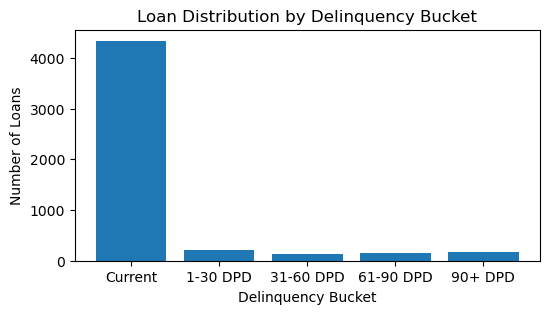

In [38]:
import matplotlib.pyplot as plt

bucket_order = ['Current', '1-30 DPD', '31-60 DPD', '61-90 DPD', '90+ DPD']

delinquency_counts = df['Delinquency_Bucket'].value_counts().reindex(bucket_order)

plt.figure(figsize=(6,3))
plt.bar(delinquency_counts.index, delinquency_counts.values)

plt.title('Loan Distribution by Delinquency Bucket')
plt.xlabel('Delinquency Bucket')
plt.ylabel('Number of Loans')

plt.show()

In [39]:
default_by_bucket = (
    df.groupby('Delinquency_Bucket')['Default_Flag']
    .mean() * 100
)

default_by_bucket = default_by_bucket.reindex(
    ['Current', '1-30 DPD', '31-60 DPD', '61-90 DPD', '90+ DPD']
)

print(default_by_bucket)

Delinquency_Bucket
Current        0.0
1-30 DPD       0.0
31-60 DPD      0.0
61-90 DPD      0.0
90+ DPD      100.0
Name: Default_Flag, dtype: float64


In [42]:
asset_summary = df.groupby('Asset_Class').agg(
    Total_Loans=('Asset_Class', 'size'),
    Total_Original_Balance=('Original_Balance_Num', 'sum'),
    Total_Current_Balance=('Current_Balance_Num', 'sum'),
    Delinquent_Loans=('Days_Past_Due', lambda x: (x > 0).sum()),
    Defaulted_Loans=('Default_Flag', 'sum')
)

asset_summary['Delinquency_Rate_%'] = (
    asset_summary['Delinquent_Loans'] / asset_summary['Total_Loans'] * 100
).round(2)

asset_summary['Default_Rate_%'] = (
    asset_summary['Defaulted_Loans'] / asset_summary['Total_Loans'] * 100
).round(2)

print(asset_summary)

                      Total_Loans  Total_Original_Balance  \
Asset_Class                                                 
Auto Loan                    1000            1.400753e+09   
Consumer Loan                2000            1.279365e+09   
Residential Mortgage         2000            6.706812e+09   

                      Total_Current_Balance  Delinquent_Loans  \
Asset_Class                                                     
Auto Loan                      7.243030e+08               121   
Consumer Loan                  6.946128e+08               262   
Residential Mortgage           5.649118e+09               275   

                      Defaulted_Loans  Delinquency_Rate_%  Default_Rate_%  
Asset_Class                                                                
Auto Loan                          33               12.10            3.30  
Consumer Loan                      49               13.10            2.45  
Residential Mortgage               84               13.75       

In [3]:
%matplotlib inline

import matplotlib.pyplot as plt

asset_balance = df.groupby('Asset_Class')['Current_Balance'].sum()

plt.figure(figsize=(7,4))

plt.bar(asset_balance.index, asset_balance.values)

plt.title('Current Balance by Asset Class')
plt.xlabel('Asset Class')
plt.ylabel('Total Current Balance')

plt.xticks(rotation=15)

plt.show()

RuntimeError: Could not convert glyph to bitmap (raster overflow; error code 0x62)

<Figure size 700x400 with 1 Axes>

In [4]:
import matplotlib.pyplot as plt

asset_summary[['Delinquency_Rate_%', 'Default_Rate_%']].plot(
    kind='bar',
    figsize=(6,3)
)

plt.title('Delinquency and Default Rate by Asset Class')
plt.xlabel('Asset Class')
plt.ylabel('Rate (%)')
plt.xticks(rotation=0)

plt.show()

NameError: name 'asset_summary' is not defined

In [10]:
import pandas as pd
import matplotlib.pyplot as plt

%matplotlib inline